# [4장 2강] 실습: 차원축소

## 실습 목표

- PCA가 분산을 최대한 보존하는 새로운 축을 찾는 원리를 설명할 수 있다.
- 구매금액 데이터에 Standardization과 PCA 기반 Feature Engineering을 적용할 수 있다.
- 6개의 구매 Feature를 2개의 주성분으로 변환할 수 있다.
- 주성분별 설명 분산 비율과 누적 설명 분산을 확인할 수 있다.
- PCA 적용 전후 Logistic Regression의 성능과 입력 차원을 비교할 수 있다.
- PCA의 계산 효율, 정보 손실과 해석 한계를 설명할 수 있다.

## 사용 데이터

- 파일: `Wholesale customers data.csv`
- PCA 입력: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`
- PCA 시각화 구분: 4장 1강과 같은 K=2 군집
- 모델 비교 Label: `Channel` (`1`과 `2`)

## 진행 방식

- 각 문제의 설명과 요구사항을 확인한 뒤 코드 셀을 작성합니다.
- 전체 데이터 PCA 시각화와 Train/Test 모델 평가는 서로 구분합니다.

## 실습 준비: 데이터 불러오기

Google Colab에서는 파일을 Google Drive의 `MyDrive`에 저장합니다. Jupyter Notebook에서는 노트북과 같은 폴더에 저장합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    file_path='/content/drive/MyDrive/Wholesale customers data.csv'
except ModuleNotFoundError:
    file_path='Wholesale customers data.csv'

wholesale_df=pd.read_csv(file_path)
display(wholesale_df.head())
print('데이터 크기:',wholesale_df.shape)
wholesale_df.info()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


데이터 크기: (440, 8)
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


## 필수 1: PCA 적용을 위한 고객 데이터 준비

### 문제 1-1: 구매 Feature 표준화와 군집 Label 생성하기

#### 문제 설명

도매 고객의 6개 품목별 구매금액은 값의 범위가 다릅니다. PCA는 분산이 큰 방향을 찾으므로, 특정 품목이 값의 크기만으로 결과를 지배하지 않도록 Standardization을 적용합니다. 이후 4장 1강과 동일한 K=2 군집을 생성하여 PCA 시각화의 색상 구분에 사용합니다.

#### 요구사항

1. 결측치와 중복 행을 확인합니다.
2. `Channel`, `Region`을 PCA 입력 Feature에서 제외합니다.
3. 6개 구매금액 Feature로 `purchase_df`를 만듭니다.
4. StandardScaler를 적용합니다.
5. 표준화 후 평균과 모집단 표준편차를 확인합니다.
6. `KMeans(n_clusters=2, random_state=42, n_init=10)`으로 군집을 생성합니다.
7. 원본을 복사한 DataFrame에 `Cluster`를 추가합니다.
8. 군집별 고객 수를 출력합니다.
9. PCA 전에 Standardization이 필요한 이유를 설명합니다.

#### 출력 결과

- 입력 데이터 크기 `(440, 6)`
- 표준화 후 평균 0, 표준편차 1에 가까운 값
- Cluster 0: 389명, Cluster 1: 51명

#### 결과 해석 작성

> PCA 전에 StandardScaler를 적용해야 하는 이유와 `Channel`, `Region`을 PCA 입력에서 제외한 이유는 무엇인가요?

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("결측치")
print(wholesale_df.isnull().sum())

print("\n중복 행 수:", wholesale_df.duplicated().sum())

purchase_df = wholesale_df.drop(columns=['Channel', 'Region'])

print("\n구매 Feature")
print(purchase_df.head())

print("\n입력 데이터 크기:", purchase_df.shape)

scaler = StandardScaler()

purchase_scaled = scaler.fit_transform(purchase_df)

purchase_scaled_df = pd.DataFrame(
    purchase_scaled,
    columns=purchase_df.columns,
    index=purchase_df.index
)


print("\n표준화 후 평균")
print(purchase_scaled_df.mean())

print("\n표준화 후 모집단 표준편차")
print(purchase_scaled_df.std(ddof=0))


kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster = kmeans.fit_predict(purchase_scaled_df)


cluster_df = wholesale_df.copy()
cluster_df['Cluster'] = cluster


print("\n군집별 고객 수")
print(cluster_df['Cluster'].value_counts().sort_index())

결측치
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

중복 행 수: 0

구매 Feature
   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669  9656     7561     214              2674        1338
1   7057  9810     9568    1762              3293        1776
2   6353  8808     7684    2405              3516        7844
3  13265  1196     4221    6404               507        1788
4  22615  5410     7198    3915              1777        5185

입력 데이터 크기: (440, 6)

표준화 후 평균
Fresh              -3.431598e-17
Milk                0.000000e+00
Grocery            -4.037175e-17
Frozen              3.633457e-17
Detergents_Paper    2.422305e-17
Delicassen         -8.074349e-18
dtype: float64

표준화 후 모집단 표준편차
Fresh               1.0
Milk                1.0
Grocery             1.0
Frozen              1.0
Detergents_Paper    1.0
Delicassen          1.0
dtype: f

## 필수 2: PCA로 6차원 데이터를 2차원으로 축소

### 문제 2-1: PCA 변환과 설명 분산 확인하기

#### 문제 설명

표준화된 6개 구매 Feature를 PC1과 PC2로 압축하고 두 축이 원본 데이터의 분산을 얼마나 설명하는지 확인합니다. 생성한 K-Means 군집을 색상으로 표시하여 2차원 공간의 고객 분포를 살펴봅니다.

#### 요구사항

1. `PCA(n_components=2)`를 생성합니다.
2. 표준화된 구매 데이터에 PCA를 적용합니다.
3. 변환 전후 차원을 출력합니다.
4. `PC1`, `PC2`, `Cluster`를 포함한 DataFrame을 만듭니다.
5. 각 주성분의 설명 분산 비율과 누적 설명 분산을 출력합니다.
6. 주성분을 구성하는 원본 Feature 계수를 표로 출력합니다.
7. PC1–PC2 산점도를 군집별로 시각화합니다.
8. PCA가 Feature 선택이 아니라 새로운 Feature 생성인 이유를 설명합니다.
9. 누적 설명 분산이 100%가 아니라는 의미를 설명합니다.

#### 결과 해석 작성

> PC1과 PC2는 원본 분산을 얼마나 설명하며, PCA가 원본 Feature 선택이 아니라 새로운 Feature 생성인 이유는 무엇인가요?

변환 전 차원: (440, 6)
변환 후 차원: (440, 2)

PCA DataFrame
        PC1       PC2  Cluster
0  0.193291 -0.305100        0
1  0.434420 -0.328413        0
2  0.811143  0.815096        0
3 -0.778648  0.652754        0
4  0.166287  1.271434        0

각 주성분의 설명 분산 비율
PC1: 0.4408 (44.08%)
PC2: 0.2838 (28.38%)

누적 설명 분산: 0.7246 (72.46%)

주성분 구성 계수
        Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
PC1  0.042884  0.545118  0.579256  0.051189          0.548640    0.248682
PC2  0.527932  0.083168 -0.146088  0.611278         -0.255233    0.504207


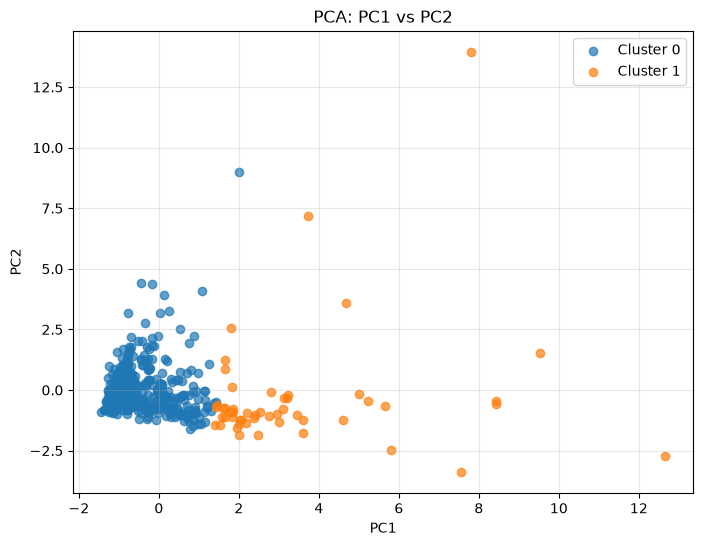

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. PCA 생성
pca = PCA(n_components=2)

# 2. 표준화된 구매 데이터에 PCA 적용
purchase_pca = pca.fit_transform(purchase_scaled_df)

# 3. 변환 전후 차원 확인
print("변환 전 차원:", purchase_scaled_df.shape)
print("변환 후 차원:", purchase_pca.shape)


# 4. PC1, PC2, Cluster DataFrame 생성
pca_df = pd.DataFrame(
    purchase_pca,
    columns=['PC1', 'PC2'],
    index=purchase_scaled_df.index
)

pca_df['Cluster'] = cluster_df['Cluster']

print("\nPCA DataFrame")
print(pca_df.head())


# 5. 설명 분산 비율과 누적 설명 분산
explained_variance = pca.explained_variance_ratio_

print("\n각 주성분의 설명 분산 비율")
print(f"PC1: {explained_variance[0]:.4f} "
      f"({explained_variance[0] * 100:.2f}%)")

print(f"PC2: {explained_variance[1]:.4f} "
      f"({explained_variance[1] * 100:.2f}%)")

print(f"\n누적 설명 분산: {explained_variance.sum():.4f} "
      f"({explained_variance.sum() * 100:.2f}%)")


# 6. 주성분을 구성하는 원본 Feature 계수
components_df = pd.DataFrame(
    pca.components_,
    columns=purchase_scaled_df.columns,
    index=['PC1', 'PC2']
)

print("\n주성분 구성 계수")
print(components_df)


# 7. PC1-PC2 산점도
plt.figure(figsize=(8, 6))

for cluster_value in sorted(pca_df['Cluster'].unique()):
    cluster_data = pca_df[pca_df['Cluster'] == cluster_value]
    
    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster_value}',
        alpha=0.7
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: PC1 vs PC2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 필수 3: PCA 전후 Logistic Regression 비교

### 문제 3-1: 원본 Feature와 PCA Feature 모델 평가하기

#### 문제 설명

PCA로 입력 차원을 줄였을 때 계산 구조와 Channel 분류 성능이 어떻게 달라지는지 확인합니다. `Channel`을 실제 예측 대상으로 사용하고 원본 6개 Feature 모델과 PCA 2개 Feature 모델을 비교합니다.

#### 요구사항

1. `Channel`에서 `1→0`, `2→1`로 변환한 값을 y로 사용합니다.
2. 원본 6개 구매 Feature를 학습 80%, 테스트 20%로 분리합니다.
3. `random_state=42`, `stratify=y`를 사용합니다.
4. 원본 모델은 `StandardScaler → LogisticRegression` Pipeline으로 구성합니다.
5. PCA 모델은 `StandardScaler → PCA(n_components=2) → LogisticRegression` Pipeline으로 구성합니다.
6. 두 모델의 Accuracy와 Confusion Matrix를 비교합니다.
7. Logistic Regression의 Weight와 Bias Shape를 확인합니다.
8. Bias를 포함한 파라미터 수를 비교합니다.
9. PCA 적용 후 성능이 유지되거나 낮아질 수 있는 이유를 설명합니다.
10. 전체 데이터 PCA와 모델 Pipeline의 PCA를 별도로 학습한 이유를 설명합니다.

#### 결과 해석 작성

> PCA 적용 후 입력 차원과 파라미터 수는 어떻게 줄었으며, 현재 데이터에서 Accuracy는 어떻게 변했나요? PCA가 항상 성능을 개선한다고 할 수 있나요?

## 실습 마무리

1. PCA는 원본 Feature를 선택하는 방법인가요?
2. 설명 분산 비율은 무엇을 의미하나요?
3. PCA의 장점과 한계는 무엇인가요?